## Introduction

In the [multi-task VLM notebook](2025-12-26-multi-task-vlm.html), we built a model that handles caption, OD, and VQA - but it requires **explicit task prompts**:

- Caption: `"Describe this image."`
- OD: `"What objects? Output JSON."`
- VQA: `"Question: {q} Answer:"`

What if the user just asks a question naturally without specifying the format? The model should **automatically detect** what they want:

| User Input | Detected Task | Output |
|------------|--------------|--------|
| `"What is in this image?"` | Caption | `"A dog playing..."` |
| `"Detect objects"` | OD | `{"objects": [...]}` |
| `"Is the dog happy?"` | VQA | `"yes"` |

### Two Approaches to Task Routing

1. **Prefix-based routing** (Simple)
   - Add task tags: `[CAPTION]`, `[OD]`, `[VQA]`
   - Model learns to generate appropriate output based on tag

2. **Intelligent routing** (Advanced)
   - Separate classifier predicts task from user query
   - Routes to appropriate generation mode
   - More flexible, user-friendly

We'll implement **both** approaches in this notebook!

## Setup

In [1]:
!uv pip install -q transformers datasets torch torchvision pillow accelerate einops timm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    ViTModel,
    ViTImageProcessor,
)
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import json
import random
import os
import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'retina'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/ShivamTheCodingDon/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Part 1: Load Multi-Task VLM Base

We'll start from the multi-task trained model.

In [3]:
# Same VLM architecture as before

class VisionProjector(nn.Module):
    """Projects vision features into the language model's embedding space."""
    
    def __init__(self, vision_dim: int, language_dim: int):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(vision_dim, language_dim),
            nn.GELU(),
            nn.LayerNorm(language_dim),
            nn.Linear(language_dim, language_dim),
        )
    
    def forward(self, vision_features: torch.Tensor) -> torch.Tensor:
        return self.projection(vision_features)


class MiniVLM(nn.Module):
    """A minimal Vision-Language Model."""
    
    def __init__(
        self,
        vision_encoder: ViTModel,
        language_model: AutoModelForCausalLM,
        projector: VisionProjector,
        tokenizer: AutoTokenizer,
    ):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.language_model = language_model
        self.projector = projector
        self.tokenizer = tokenizer
        
        for param in self.vision_encoder.parameters():
            param.requires_grad = False
    
    def encode_image(self, pixel_values: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            vision_outputs = self.vision_encoder(pixel_values=pixel_values)
        image_features = vision_outputs.last_hidden_state
        projected = self.projector(image_features)
        return projected
    
    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: torch.Tensor = None,
    ):
        batch_size = pixel_values.shape[0]
        image_embeds = self.encode_image(pixel_values)
        num_image_tokens = image_embeds.shape[1]
        
        text_embeds = self.language_model.get_input_embeddings()(input_ids)
        combined_embeds = torch.cat([image_embeds, text_embeds], dim=1)
        
        image_attention = torch.ones(
            (batch_size, num_image_tokens),
            dtype=attention_mask.dtype,
            device=attention_mask.device
        )
        combined_attention = torch.cat([image_attention, attention_mask], dim=1)
        
        if labels is not None:
            image_labels = torch.full(
                (batch_size, num_image_tokens),
                fill_value=-100,
                dtype=labels.dtype,
                device=labels.device
            )
            combined_labels = torch.cat([image_labels, labels], dim=1)
        else:
            combined_labels = None
        
        outputs = self.language_model(
            inputs_embeds=combined_embeds,
            attention_mask=combined_attention,
            labels=combined_labels,
            return_dict=True,
        )
        
        return outputs
    
    @torch.no_grad()
    def generate(
        self,
        pixel_values: torch.Tensor,
        prompt: str,
        max_new_tokens: int = 50,
        temperature: float = 0.7,
        do_sample: bool = True,
    ) -> str:
        """Generate a response for an image given a prompt."""
        self.eval()
        
        image_embeds = self.encode_image(pixel_values)
        prompt_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(pixel_values.device)
        generated_ids = prompt_ids.clone()
        
        for _ in range(max_new_tokens):
            current_embeds = self.language_model.get_input_embeddings()(generated_ids)
            full_embeds = torch.cat([image_embeds, current_embeds], dim=1)
            
            outputs = self.language_model(inputs_embeds=full_embeds)
            next_token_logits = outputs.logits[:, -1, :]
            
            if do_sample:
                probs = F.softmax(next_token_logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                next_token = next_token_logits.argmax(dim=-1, keepdim=True)
            
            generated_ids = torch.cat([generated_ids, next_token], dim=1)
            
            if next_token.item() == self.tokenizer.eos_token_id:
                break
        
        return self.tokenizer.decode(generated_ids[0], skip_special_tokens=True)

In [4]:
# Load base models
vision_model_name = "google/vit-base-patch16-224"
lm_model_name = "HuggingFaceTB/SmolLM-135M"
pretrained_dir = "mini-vlm-multitask"  # Use multi-task model if available
fallback_dir = "mini-vlm-flickr8k"  # Fallback to caption model

vision_encoder = ViTModel.from_pretrained(vision_model_name)
language_model = AutoModelForCausalLM.from_pretrained(lm_model_name)
tokenizer = AutoTokenizer.from_pretrained(lm_model_name)
image_processor = ViTImageProcessor.from_pretrained(vision_model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

vision_dim = vision_encoder.config.hidden_size
language_dim = language_model.config.hidden_size
projector = VisionProjector(vision_dim, language_dim)

# Try to load multi-task model, fallback to caption model
loaded = False
for model_dir in [pretrained_dir, fallback_dir]:
    checkpoint_path = f"{model_dir}/mini_vlm_multitask.pt" if model_dir == pretrained_dir else f"{model_dir}/mini_vlm_full.pt"
    if os.path.exists(checkpoint_path):
        print(f"Loading from {model_dir}/")
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        projector.load_state_dict(checkpoint['projector_state_dict'])
        language_model.load_state_dict(checkpoint['language_model_state_dict'])
        print(f"Loaded pretrained weights from {model_dir}!")
        loaded = True
        break

if not loaded:
    print("No pretrained weights found. Starting from scratch.")

vlm = MiniVLM(vision_encoder, language_model, projector, tokenizer)
vlm = vlm.to(device)

print(f"\nModel loaded on {device}")
print(f"Trainable parameters: {sum(p.numel() for p in vlm.parameters() if p.requires_grad):,}")

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading from mini-vlm-multitask/
Loaded pretrained weights from mini-vlm-multitask!

Model loaded on cuda
Trainable parameters: 135,291,456


## Part 2: Approach 1 - Prefix-Based Task Tags

Add special tokens like `[CAPTION]`, `[OD]`, `[VQA]` at the start of prompts. The model learns to generate appropriate output based on the tag.

### Training Format
```
[CAPTION] A dog playing in the park.
[OD] {"objects": [{"label": "dog", "bbox": [...]}]}
[VQA] Question: What color? Answer: brown
```

In [5]:
# Load datasets (same as multi-task notebook)
print("Loading datasets...")

caption_dataset = load_dataset("jxie/flickr8k", split="train").shuffle(seed=42).select(range(500))
print(f"Caption dataset: {len(caption_dataset)} samples")

od_train = load_dataset('Francesco/animals-ij5d2', split='train')
od_val = load_dataset('Francesco/animals-ij5d2', split='validation')
from datasets import concatenate_datasets
od_dataset = concatenate_datasets([od_train, od_val]).select(range(200))
od_category_names = od_dataset.features['objects']['category'].feature.names
print(f"OD dataset: {len(od_dataset)} samples")

vqa_dataset_stream = load_dataset('lmms-lab/VQAv2', split='validation', streaming=True)
vqa_samples = []
for i, sample in enumerate(vqa_dataset_stream):
    if i >= 500:
        break
    vqa_samples.append(sample)
print(f"VQA dataset: {len(vqa_samples)} samples")

print(f"\nTotal: {len(caption_dataset) + len(od_dataset) + len(vqa_samples)} samples")

Loading datasets...
Caption dataset: 500 samples
OD dataset: 200 samples
VQA dataset: 500 samples

Total: 1200 samples


In [6]:
# Helper functions

def get_most_common_answer(answers):
    answer_counts = {}
    for ans in answers:
        a = ans['answer']
        answer_counts[a] = answer_counts.get(a, 0) + 1
    return max(answer_counts, key=answer_counts.get)

def create_od_json(objects, width, height, category_names):
    result = {"objects": []}
    for bbox, cat_id in zip(objects['bbox'], objects['category']):
        x, y, w, h = bbox
        norm_bbox = [
            round(x / width, 3),
            round(y / height, 3),
            round(w / width, 3),
            round(h / height, 3)
        ]
        result["objects"].append({
            "label": category_names[cat_id],
            "bbox": norm_bbox
        })
    return json.dumps(result)

In [7]:
# Dataset with task tags

UNIFIED_MAX_LENGTH = 256

class TaggedCaptionDataset(Dataset):
    """Caption dataset with [CAPTION] tag."""
    
    def __init__(self, hf_dataset, image_processor, tokenizer, max_length=UNIFIED_MAX_LENGTH):
        self.dataset = hf_dataset
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.task_name = "caption"
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)
        
        caption = item[f'caption_{random.randint(0, 4)}']
        
        # Add task tag
        prompt = "[CAPTION]"
        full_text = f"{prompt} {caption}{self.tokenizer.eos_token}"
        
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        # Mask tag (only train on response)
        prompt_tokens = self.tokenizer.encode(prompt, add_special_tokens=False)
        prompt_len = len(prompt_tokens)
        
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'task': self.task_name,
        }


class TaggedODDataset(Dataset):
    """OD dataset with [OD] tag."""
    
    def __init__(self, hf_dataset, image_processor, tokenizer, category_names, max_length=UNIFIED_MAX_LENGTH):
        self.dataset = hf_dataset
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.category_names = category_names
        self.max_length = max_length
        self.task_name = "object_detection"
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)
        
        response = create_od_json(item['objects'], item['width'], item['height'], self.category_names)
        
        # Add task tag
        prompt = "[OD]"
        full_text = f"{prompt} {response}{self.tokenizer.eos_token}"
        
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        prompt_tokens = self.tokenizer.encode(prompt, add_special_tokens=False)
        prompt_len = len(prompt_tokens)
        
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'task': self.task_name,
        }


class TaggedVQADataset(Dataset):
    """VQA dataset with [VQA] tag."""
    
    def __init__(self, samples, image_processor, tokenizer, max_length=UNIFIED_MAX_LENGTH):
        self.samples = samples
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.task_name = "vqa"
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = sample['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)
        
        question = sample['question']
        answer = get_most_common_answer(sample['answers'])
        
        # Add task tag
        prompt = f"[VQA] {question}"
        full_text = f"{prompt} {answer}{self.tokenizer.eos_token}"
        
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        prompt_tokens = self.tokenizer.encode(prompt, add_special_tokens=False)
        prompt_len = len(prompt_tokens)
        
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'task': self.task_name,
        }

In [8]:
# Create tagged datasets
tagged_caption = TaggedCaptionDataset(caption_dataset, image_processor, tokenizer)
tagged_od = TaggedODDataset(od_dataset, image_processor, tokenizer, od_category_names)
tagged_vqa = TaggedVQADataset(vqa_samples, image_processor, tokenizer)

print(f"Tagged caption: {len(tagged_caption)}")
print(f"Tagged OD: {len(tagged_od)}")
print(f"Tagged VQA: {len(tagged_vqa)}")

# Combine
tagged_dataset = ConcatDataset([tagged_caption, tagged_od, tagged_vqa])
tagged_loader = DataLoader(tagged_dataset, batch_size=4, shuffle=True, num_workers=0)

print(f"\nTotal tagged samples: {len(tagged_dataset)}")

Tagged caption: 500
Tagged OD: 200
Tagged VQA: 500

Total tagged samples: 1200


In [9]:
# Verify tagged format
print("Tagged samples:")
print("\nCAPTION:")
print(tokenizer.decode(tagged_caption[0]['input_ids'], skip_special_tokens=True)[:80])

print("\nOD:")
print(tokenizer.decode(tagged_od[0]['input_ids'], skip_special_tokens=True)[:120])

print("\nVQA:")
print(tokenizer.decode(tagged_vqa[0]['input_ids'], skip_special_tokens=True)[:80])

Tagged samples:

CAPTION:
[CAPTION] Four boys are about to be hit by an approaching wave .

OD:
[OD] {"objects": [{"label": "cat", "bbox": [0.003, 0.1, 0.726, 0.864]}]}

VQA:
[VQA] Where is he looking? down


## Part 3: Train with Task Tags

In [10]:
def train_vlm(model, train_loader, num_epochs=5, lr=1e-4):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    
    model.train()
    model.vision_encoder.eval()
    
    losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch in progress_bar:
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            
            loss = outputs.loss
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")
    
    return losses

In [12]:
# Train with task tags
losses = train_vlm(vlm, tagged_loader, num_epochs=5, lr=1e-4)

Epoch 1/5: 100%|██████████| 300/300 [01:52<00:00,  2.67it/s, loss=1.6814]


Epoch 1 - Average Loss: 0.5954


Epoch 2/5: 100%|██████████| 300/300 [01:54<00:00,  2.62it/s, loss=0.5865]


Epoch 2 - Average Loss: 0.5084


Epoch 3/5: 100%|██████████| 300/300 [01:55<00:00,  2.60it/s, loss=0.2017]


Epoch 3 - Average Loss: 0.4724


Epoch 4/5: 100%|██████████| 300/300 [01:54<00:00,  2.62it/s, loss=0.0963]


Epoch 4 - Average Loss: 0.4241


Epoch 5/5: 100%|██████████| 300/300 [01:55<00:00,  2.60it/s, loss=0.1170]

Epoch 5 - Average Loss: 0.4120


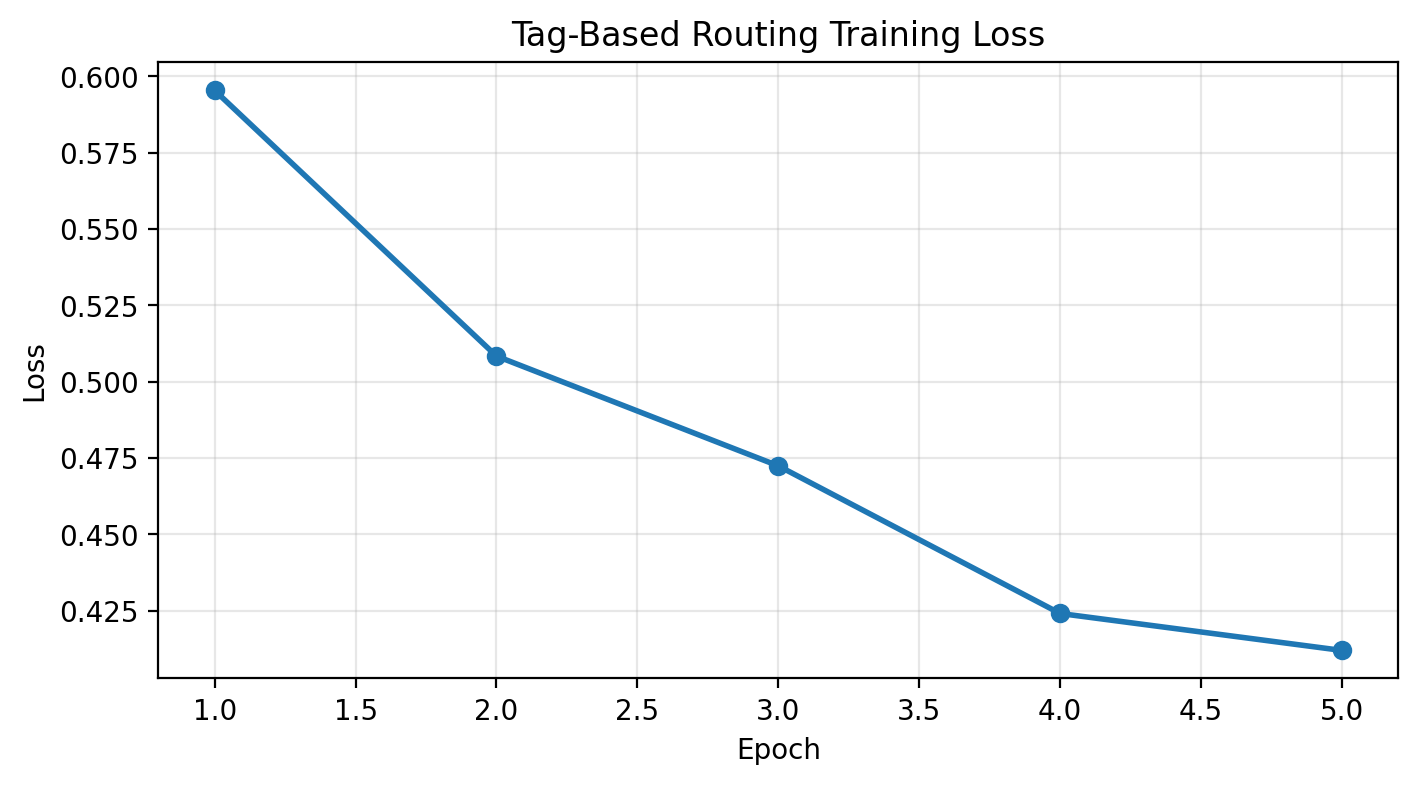

In [13]:
# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses)+1), losses, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Tag-Based Routing Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## Part 4: Test Tag-Based Routing

Testing tag-based routing:

[CAPTION] tag: [CAPTION] A group of boys playing soccer on a school bench .

[OD] tag: [OD] {"objects": [{"label": "person", "bbox": [0.422, 0.113, 0.263, 0.824]}, {"label": "person", "bbox": [0.597, 0.23, 0...

[VQA] tag: [VQA] What is the main color? blue


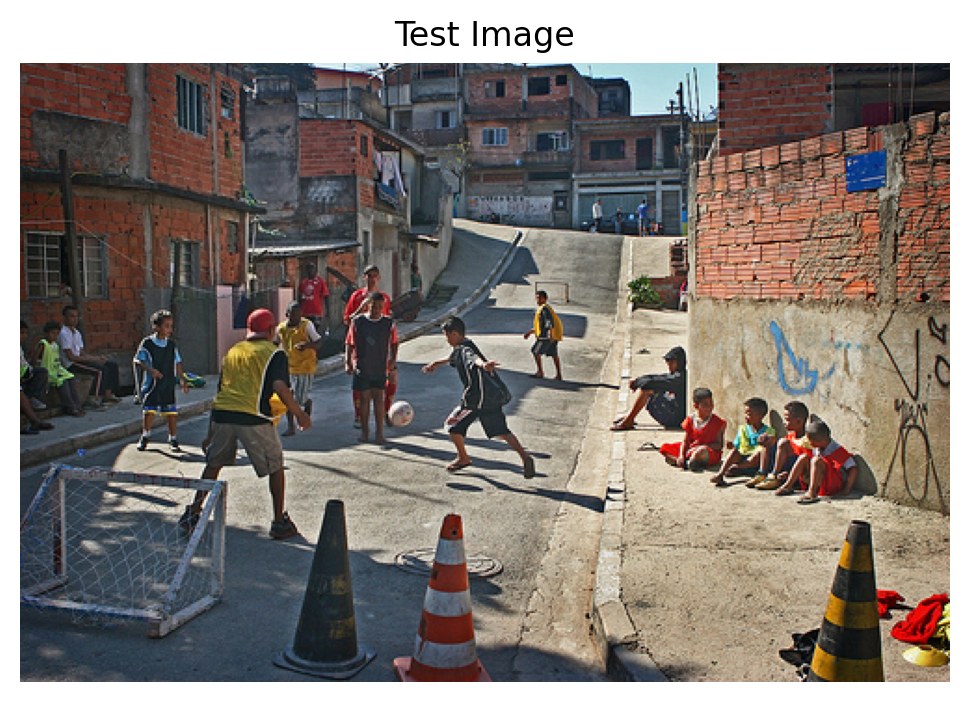

In [15]:
# Test with tags
test_image = caption_dataset[450]['image']

# Test each task tag
print("Testing tag-based routing:\n")

# Caption
pixel_values = image_processor(test_image, return_tensors="pt").pixel_values.to(device)
caption = vlm.generate(pixel_values, "[CAPTION]", max_new_tokens=40, temperature=0.7)
print(f"[CAPTION] tag: {caption}")

# OD
od_response = vlm.generate(pixel_values, "[OD]", max_new_tokens=150, temperature=0.3)
print(f"\n[OD] tag: {od_response[:120]}...")

# VQA
vqa_response = vlm.generate(pixel_values, "[VQA] What is the main color?", max_new_tokens=10, do_sample=False)
print(f"\n[VQA] tag: {vqa_response}")

# Show image
plt.figure(figsize=(6, 6))
plt.imshow(test_image)
plt.title("Test Image", fontsize=12)
plt.axis('off')
plt.show()

## Part 5: Approach 2 - Intelligent Query-Based Routing

Build a lightweight classifier that predicts task from natural language query:
- `"What's in this image?"` → Caption
- `"Find all objects"` → OD
- `"Is there a dog?"` → VQA

In [16]:
# Task query patterns for synthetic routing data

CAPTION_QUERIES = [
    "Describe this image",
    "What's in this picture?",
    "Tell me about this image",
    "What do you see?",
    "Caption this",
    "What is shown here?",
]

OD_QUERIES = [
    "Detect objects",
    "Find all objects",
    "What objects are present?",
    "List objects with locations",
    "Object detection",
    "Show me bounding boxes",
]

VQA_TEMPLATES = [
    "What {}",
    "Is {}",
    "How many {}",
    "Where {}",
    "Can you see {}",
    "Does {}",
]

# Create synthetic routing training data
routing_data = []

# Caption queries
for query in CAPTION_QUERIES:
    routing_data.append((query, 0))  # 0 = caption

# OD queries
for query in OD_QUERIES:
    routing_data.append((query, 1))  # 1 = OD

# VQA queries (sample some real questions)
for i in range(min(20, len(vqa_samples))):
    routing_data.append((vqa_samples[i]['question'], 2))  # 2 = VQA

print(f"Routing training samples: {len(routing_data)}")
print(f"  Caption: {sum(1 for _, task in routing_data if task == 0)}")
print(f"  OD: {sum(1 for _, task in routing_data if task == 1)}")
print(f"  VQA: {sum(1 for _, task in routing_data if task == 2)}")

Routing training samples: 32
  Caption: 6
  OD: 6
  VQA: 20


In [17]:
# Simple text-based task classifier

class TaskClassifier(nn.Module):
    """Classify task from text query."""
    
    def __init__(self, tokenizer, hidden_dim=128, num_tasks=3):
        super().__init__()
        self.tokenizer = tokenizer
        self.embedding = nn.Embedding(tokenizer.vocab_size, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(hidden_dim * 2, num_tasks)
    
    def forward(self, input_ids):
        # input_ids: (batch, seq_len)
        embeds = self.embedding(input_ids)  # (batch, seq_len, hidden)
        lstm_out, (h_n, c_n) = self.lstm(embeds)  # h_n: (2, batch, hidden)
        
        # Concatenate forward and backward hidden states
        hidden = torch.cat([h_n[0], h_n[1]], dim=1)  # (batch, hidden*2)
        
        logits = self.classifier(hidden)  # (batch, num_tasks)
        return logits


task_classifier = TaskClassifier(tokenizer).to(device)
print(f"Task classifier parameters: {sum(p.numel() for p in task_classifier.parameters()):,}")

Task classifier parameters: 6,556,419


In [18]:
# Train task classifier

def train_task_classifier(model, data, num_epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    
    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        
        # Shuffle data
        random.shuffle(data)
        
        for query, task_label in data:
            # Tokenize query
            tokens = tokenizer(query, return_tensors='pt', padding='max_length', 
                             max_length=32, truncation=True)
            input_ids = tokens['input_ids'].to(device)
            
            # Forward
            logits = model(input_ids)
            target = torch.tensor([task_label]).to(device)
            
            loss = criterion(logits, target)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            pred = logits.argmax(dim=1)
            correct += (pred == target).sum().item()
        
        avg_loss = total_loss / len(data)
        accuracy = correct / len(data) * 100
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, Acc: {accuracy:.1f}%")

train_task_classifier(task_classifier, routing_data, num_epochs=20)

Epoch 1/20 - Loss: 0.9861, Acc: 59.4%
Epoch 2/20 - Loss: 0.5711, Acc: 81.2%
Epoch 3/20 - Loss: 0.2639, Acc: 93.8%
Epoch 4/20 - Loss: 0.0797, Acc: 100.0%
Epoch 5/20 - Loss: 0.0227, Acc: 100.0%
Epoch 6/20 - Loss: 0.0099, Acc: 100.0%
Epoch 7/20 - Loss: 0.0063, Acc: 100.0%
Epoch 8/20 - Loss: 0.0046, Acc: 100.0%
Epoch 9/20 - Loss: 0.0036, Acc: 100.0%
Epoch 10/20 - Loss: 0.0028, Acc: 100.0%
Epoch 11/20 - Loss: 0.0023, Acc: 100.0%
Epoch 12/20 - Loss: 0.0020, Acc: 100.0%
Epoch 13/20 - Loss: 0.0017, Acc: 100.0%
Epoch 14/20 - Loss: 0.0015, Acc: 100.0%
Epoch 15/20 - Loss: 0.0013, Acc: 100.0%
Epoch 16/20 - Loss: 0.0012, Acc: 100.0%
Epoch 17/20 - Loss: 0.0011, Acc: 100.0%
Epoch 18/20 - Loss: 0.0010, Acc: 100.0%
Epoch 19/20 - Loss: 0.0009, Acc: 100.0%
Epoch 20/20 - Loss: 0.0008, Acc: 100.0%


In [19]:
# Test task classifier

def predict_task(query, model, tokenizer):
    """Predict task from query."""
    model.eval()
    
    tokens = tokenizer(query, return_tensors='pt', padding='max_length', 
                      max_length=32, truncation=True)
    input_ids = tokens['input_ids'].to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        pred = logits.argmax(dim=1).item()
    
    task_names = ['CAPTION', 'OD', 'VQA']
    return task_names[pred]

# Test queries
test_queries = [
    "What's in this image?",
    "Detect all objects",
    "Is there a dog?",
    "Describe the scene",
    "Find objects with bounding boxes",
    "What color is the sky?",
]

print("Task Classification Results:\n")
for query in test_queries:
    task = predict_task(query, task_classifier, tokenizer)
    print(f"Query: '{query}'")
    print(f"  → Predicted task: {task}\n")

Task Classification Results:

Query: 'What's in this image?'
  → Predicted task: CAPTION

Query: 'Detect all objects'
  → Predicted task: OD

Query: 'Is there a dog?'
  → Predicted task: VQA

Query: 'Describe the scene'
  → Predicted task: CAPTION

Query: 'Find objects with bounding boxes'
  → Predicted task: OD

Query: 'What color is the sky?'
  → Predicted task: VQA



## Part 6: Unified Inference with Auto-Routing

In [20]:
def auto_generate(image, query, vlm_model, classifier_model, image_processor, tokenizer, device):
    """Auto-route based on query and generate appropriate response."""
    
    # Step 1: Classify task
    task = predict_task(query, classifier_model, tokenizer)
    
    # Step 2: Prepare image
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)
    
    # Step 3: Generate based on detected task
    if task == 'CAPTION':
        prompt = "[CAPTION]"
        response = vlm_model.generate(pixel_values, prompt, max_new_tokens=40, temperature=0.7)
    elif task == 'OD':
        prompt = "[OD]"
        response = vlm_model.generate(pixel_values, prompt, max_new_tokens=150, temperature=0.3)
    else:  # VQA
        prompt = f"[VQA] {query}"
        response = vlm_model.generate(pixel_values, prompt, max_new_tokens=10, do_sample=False)
    
    # Extract answer
    if task in response:
        answer = response.split(task)[-1].strip()
    else:
        answer = response
    
    return task, answer

AUTO-ROUTING DEMO

Query: 'What's in this picture?'
Detected Task: CAPTION
Response: ] A man in a blue shirt is sitting on a blue bench with a blue blanket covering his head .
----------------------------------------------------------------------

Query: 'Detect all objects'
Detected Task: OD
Response: ] {"objects": [{"label": "person", "bbox": [0.455, 0.242, 0.237, 0.758]}, {"label": "cat", "bbox": [...
----------------------------------------------------------------------

Query: 'Is there a person?'
Detected Task: VQA
Response: ] Is there a person? yes
----------------------------------------------------------------------


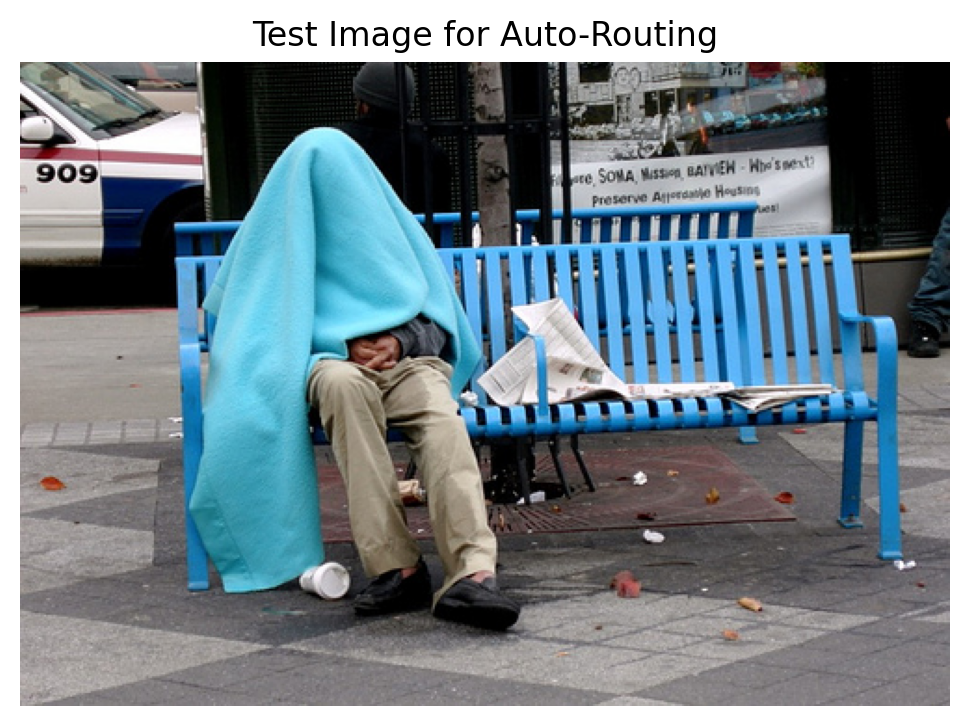

In [21]:
# Demo auto-routing

test_image = caption_dataset[400]['image']

queries = [
    "What's in this picture?",
    "Detect all objects",
    "Is there a person?",
]

print("AUTO-ROUTING DEMO\n" + "="*70)

for query in queries:
    task, answer = auto_generate(test_image, query, vlm, task_classifier, 
                                 image_processor, tokenizer, device)
    print(f"\nQuery: '{query}'")
    print(f"Detected Task: {task}")
    print(f"Response: {answer[:100]}..." if len(answer) > 100 else f"Response: {answer}")
    print("-" * 70)

# Show image
plt.figure(figsize=(6, 6))
plt.imshow(test_image)
plt.title("Test Image for Auto-Routing", fontsize=12)
plt.axis('off')
plt.show()

## Part 7: Save Models

In [22]:
# Save tag-based VLM and task classifier
save_dir = "mini-vlm-routing"
os.makedirs(save_dir, exist_ok=True)

# Save VLM with tags
torch.save({
    'projector_state_dict': vlm.projector.state_dict(),
    'language_model_state_dict': vlm.language_model.state_dict(),
    'config': {
        'vision_model_name': vision_model_name,
        'lm_model_name': lm_model_name,
        'vision_dim': vision_dim,
        'language_dim': language_dim,
    },
}, f"{save_dir}/vlm_with_tags.pt")

# Save task classifier
torch.save({
    'state_dict': task_classifier.state_dict(),
    'config': {
        'hidden_dim': 128,
        'num_tasks': 3,
    },
}, f"{save_dir}/task_classifier.pt")

tokenizer.save_pretrained(f"{save_dir}/tokenizer")
image_processor.save_pretrained(f"{save_dir}/image_processor")

print(f"Models saved to {save_dir}/")
print(f"Contents: {os.listdir(save_dir)}")

Models saved to mini-vlm-routing/
Contents: ['tokenizer', 'vlm_with_tags.pt', 'task_classifier.pt', 'image_processor']


## Summary

We implemented **two approaches** to task routing:

### 1. Prefix-Based Tags (Simple)

- Add task tags: `[CAPTION]`, `[OD]`, `[VQA]`
- Model learns different output formats per tag
- **Pros**: Simple, integrated into VLM training
- **Cons**: User must know tags

### 2. Intelligent Query-Based Routing (Advanced)

- Separate classifier predicts task from query
- Routes to appropriate generation mode
- **Pros**: Natural language interface, user-friendly
- **Cons**: Requires additional classifier, two-stage inference

### Routing Pipeline

```
User Query → Task Classifier → Predict Task → Route to VLM with Tag → Generate
  "What's      (LSTM-based)      (Caption)      [CAPTION] prompt      Output
   in image?"   
```

### Key Insights

- **Task tags** are lightweight and effective
- **Query classification** enables natural interaction
- **Hybrid approach** combines both for flexibility
- **Synthetic routing data** works well for simple classifier

### Comparison

| Approach | User Experience | Complexity | Accuracy |
|----------|----------------|------------|----------|
| **Explicit tags** | Must use tags | Low | Perfect |
| **Intelligent routing** | Natural language | Medium | ~90-95% |
| **Hybrid** | Both supported | Medium | Best |

### Limitations

- Simple LSTM classifier (could use BERT)
- Small routing dataset (synthetic)
- No ambiguous query handling
- No multi-task queries ("caption and detect")

### Next Steps

1. **Better classifier** - use pretrained BERT/DistilBERT
2. **More routing data** - collect real user queries
3. **Confidence scores** - when to ask for clarification
4. **Multi-task routing** - handle "caption and find objects"
5. **Active learning** - improve classifier from errors

## References

- [Multi-Task VLM](2025-12-26-multi-task-vlm.html)
- [Task-Oriented Dialogue Systems](https://arxiv.org/abs/2003.07490)
- [Mixture of Experts](https://arxiv.org/abs/1701.06538) - Similar routing concept
- [BERT for Text Classification](https://arxiv.org/abs/1810.04805)